<a href="https://colab.research.google.com/github/riddhima-shetty/MyWorkspace/blob/main/Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
file_path = '/content/carbon_emission_dataset_with_Industry.csv.xlsx'
df = pd.read_excel(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,...,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,...,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,...,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,...,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,...,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,...,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_percentage_error
import numpy as np

# Print all columns to debug KeyError
print("DataFrame columns:")
print(df.columns)

# Corrected target variable name based on the printed DataFrame columns
TARGET_COLUMN = 'Carbon_Emission_tCO2e_TARGET'

# Drop non-predictive columns and the target variable for feature matrix
X = df.drop(columns=['Company_ID', 'Date', TARGET_COLUMN], errors='ignore')
y = df[TARGET_COLUMN]

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

DataFrame columns:
Index(['Company_ID', 'Date', 'Sector', 'Total_Energy_Consumption_kWh',
       'Renewable_Energy_Consumption_kWh',
       'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units',
       'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode',
       'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET',
       'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent',
       'Employment_Count', 'Public_Acceptance_Index',
       'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD',
       'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent',
       'Social_Impact_Score', 'Industry_Sectors'],
      dtype='object')
Shape of X_train: (14600, 28)
Shape of X_test: (3650, 28)
Shape of y_train: (14600,)
Shape of y_test: (3650,)


In [ ]:
# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
accuracy = (1 - mape) * 100
print(f"Accuracy: {accuracy:.2f}%")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Accuracy: 89.39%
Mean Squared Error: 18.79
R-squared: 0.91


--- Top 5 Pollution Drivers ---
                               Feature  Importance
2  NonRenewable_Energy_Consumption_kWh    0.877424
7                       Carbon_Tax_USD    0.048535
5                Raw_Material_Usage_kg    0.006082
3              Production_Output_Units    0.005964
8           Process_Efficiency_Percent    0.005754


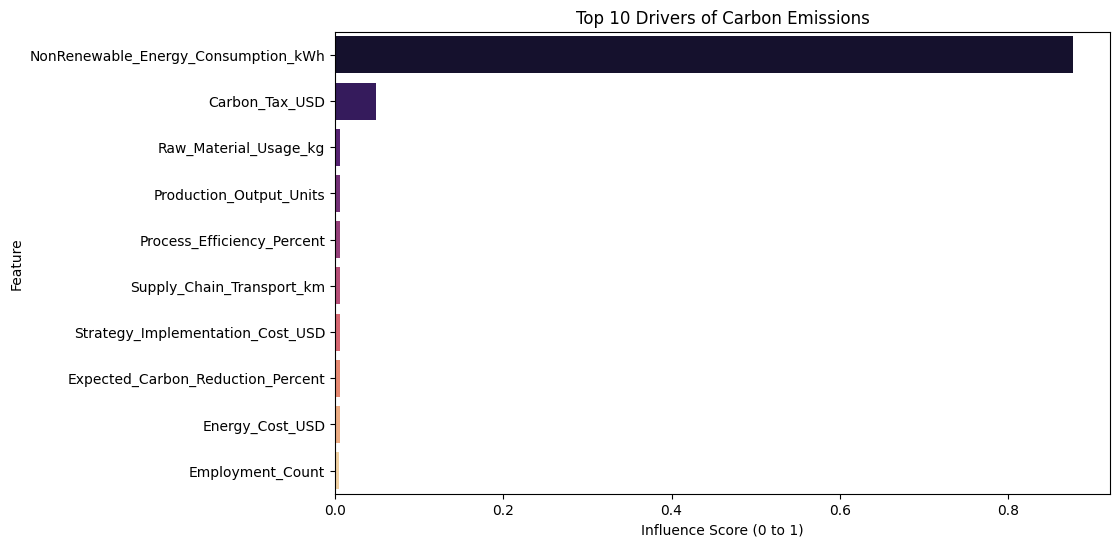

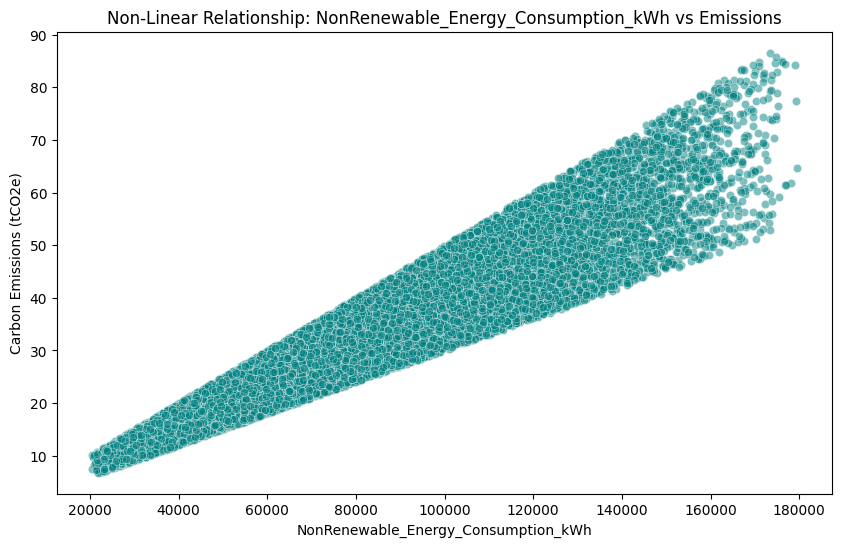

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. FEATURE IMPORTANCE (Pollution Drivers)
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- Top 5 Pollution Drivers ---")
print(feature_importance_df.head(5))

# 7. VISUALIZATIONS
# Plot 1: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Drivers of Carbon Emissions')
plt.xlabel('Influence Score (0 to 1)')
plt.show()

# Plot 2: Visualizing Non-Linearity (Top Feature vs. Target)
# We use the #1 feature identified by the model
top_feature = feature_importance_df.iloc[0]['Feature']
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[top_feature], y=df[TARGET_COLUMN], alpha=0.5, color='teal')
plt.title(f'Non-Linear Relationship: {top_feature} vs Emissions')
plt.xlabel(top_feature)
plt.ylabel('Carbon Emissions (tCO2e)')
plt.show()

### **Classification: Environmental Regulation Audit (Pass/Fail)**

Let's now use the same dataset to perform a classification task: predicting whether a company will 'Pass' or 'Fail' an environmental regulation audit. We'll define 'Pass' as having `Carbon_Emission_tCO2e_TARGET` below a certain threshold, and 'Fail' otherwise.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Define a threshold for 'Pass'/'Fail' (e.g., companies with carbon emissions > 30 tCO2e 'Fail')
# This threshold can be adjusted based on regulatory standards or business needs.
EMISSION_THRESHOLD = 30

# Create the binary target variable for classification
# 0 for Pass (emissions <= threshold), 1 for Fail (emissions > threshold)
y_classification = (df[TARGET_COLUMN] > EMISSION_THRESHOLD).astype(int)

# Split the data into training and testing sets for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size=0.2, random_state=42)

print(f"Shape of X_train_cls: {X_train_cls.shape}")
print(f"Shape of X_test_cls: {X_test_cls.shape}")
print(f"Shape of y_train_cls: {y_train_cls.shape}")
print(f"Shape of y_test_cls: {y_test_cls.shape}")
print(f"Emission Threshold for Failure: {EMISSION_THRESHOLD} tCO2e")

Shape of X_train_cls: (14600, 28)
Shape of X_test_cls: (3650, 28)
Shape of y_train_cls: (14600,)
Shape of y_test_cls: (3650,)
Emission Threshold for Failure: 30 tCO2e


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Scale the features for better convergence, especially with 'lbfgs' or 'saga'
scaler = StandardScaler()
X_train_cls_scaled = scaler.fit_transform(X_train_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

# Initialize and train the Logistic Regression model with 'liblinear' solver (often good for smaller datasets and efficient)
# Alternatively, 'saga' is a good general-purpose solver for larger datasets that supports all penalties.
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train_cls_scaled, y_train_cls)

# Make predictions on the test set
y_pred_cls = log_reg_model.predict(X_test_cls_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print("--- Logistic Regression Model Performance (Classification) ---")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

--- Logistic Regression Model Performance (Classification) ---
Accuracy: 0.91
Precision: 0.92
Recall: 0.91
F1-Score: 0.91


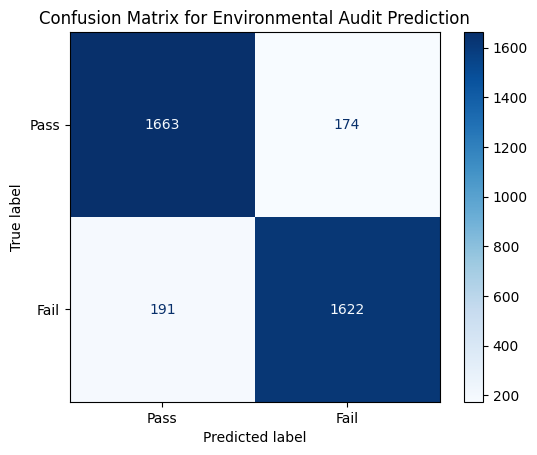

In [ ]:
# Plot the Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Environmental Audit Prediction')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Display the classification report
print("--- Classification Report ---")
print(classification_report(y_test_cls, y_pred_cls, target_names=['Pass', 'Fail']))

--- Classification Report ---
              precision    recall  f1-score   support

        Pass       0.90      0.91      0.90      1837
        Fail       0.90      0.89      0.90      1813

    accuracy                           0.90      3650
   macro avg       0.90      0.90      0.90      3650
weighted avg       0.90      0.90      0.90      3650



In [ ]:
# Example: Get a 'Pass' or 'Fail' statement for a new (or existing) data point

# Let's take the first instance from the test set for demonstration
sample_data_point = X_test_cls.iloc[[0]]
actual_label = y_test_cls.iloc[0]

# Make a prediction
prediction = log_reg_model.predict(sample_data_point)

# Map the numerical prediction to 'Pass' or 'Fail'
prediction_status = 'Fail' if prediction[0] == 1 else 'Pass'
actual_status = 'Fail' if actual_label == 1 else 'Pass'

print(f"For the selected data point:")
print(f"- The model predicts the audit status is: {prediction_status}")
print(f"- The actual audit status was: {actual_status}")

For the selected data point:
- The model predicts the audit status is: Fail
- The actual audit status was: Fail
